<a href="https://colab.research.google.com/github/amit491/Mutational_order_Cell_state_manuscript/blob/main/scRNASeq/GutAtlas_gene_signatures/ElmDat_inspection_13Apr2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is because on pB the LBowel set:
See notebooks-
the 30Mar2026 inspection
and the pB DeSeq 02Apr2026

There aren't any replicates left for Paneth and EECs.
So, for those two cell types I'm attempting a pB _with SmallInt included_

# Set-up

In [ ]:
!pip install scanpy decoupler pydeseq2 watermark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.9/121.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 106.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━

In [ ]:
# Import the pkgs
import os
import multiprocessing
import scipy as sp
import scanpy as sc
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import decoupler as dc
import pickle as pickle
from google.colab import drive
# For session info
%load_ext watermark

In [ ]:
multiprocessing.cpu_count()

8

In [ ]:
os.getcwd()

'/content'

In [ ]:
drive.mount('/content/my_drive')

Mounted at /content/my_drive


In [ ]:
my_dir = "/content/my_drive/MyDrive/colab_IO/"

In [ ]:
if os.path.exists(os.path.join(my_dir,'GutAtlas.dat/')):
  print('Dir. present!')
else:
  print('Dir. not found!')
#

Dir. present!


# Load Elm dat.// Epi. specific subset// Raw counts

In [ ]:
# Elmentaite et al. Epi. subset dat // Raw counts
Elm_Epi_Rx = sc.read_h5ad(os.path.join(my_dir,"GutAtlas.dat/epi_raw_counts02_v2.h5ad"))

In [ ]:
Elm_Epi_Rx

AnnData object with n_obs × n_vars = 142113 × 33538
    obs: 'Sample name', 'Diagnosis', 'Age', 'sample name', 'Region code', 'Fraction', 'Gender', 'Region', '10X', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_scores', 'predicted_doublets', 'category', 'Age_group', 'annotation', 'S_score', 'G2M_score', 'phase'
    var: 'gene_ids', 'feature_types'

In [ ]:
Elm_Epi_Rx.obs.category.value_counts()

,count
category,
Epithelial,142104
Mesenchymal,9


In [ ]:
Elm_Epi_Rx.obs.Diagnosis.value_counts()

,count
Diagnosis,
Healthy adult,77364
fetal,52194
Pediatric healthy,8157
Pediatric Crohn Disease,4398


In [ ]:
Elm_Epi_Rx.obs.Region.value_counts()

,count
Region,
SmallInt,73023
LargeInt,47020
REC,17348
APD,4689
lymph node,33


# Subset out a 'Gut' set

In [ ]:
Elm_Gut_Rx = Elm_Epi_Rx[(Elm_Epi_Rx.obs['Region'].isin(['LargeInt','REC','SmallInt','APD'])) &
 (Elm_Epi_Rx.obs['category'] == 'Epithelial') &
  (Elm_Epi_Rx.obs['Diagnosis'].isin(['Healthy adult','fetal','Pediatric healthy']))]

In [ ]:
Elm_Gut_Rx

View of AnnData object with n_obs × n_vars = 137673 × 33538
    obs: 'Sample name', 'Diagnosis', 'Age', 'sample name', 'Region code', 'Fraction', 'Gender', 'Region', '10X', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_scores', 'predicted_doublets', 'category', 'Age_group', 'annotation', 'S_score', 'G2M_score', 'phase'
    var: 'gene_ids', 'feature_types'

In [ ]:
Elm_Gut_Rx.obs.category.value_counts()

,count
category,
Epithelial,137673


In [ ]:
Elm_Gut_Rx.obs.Diagnosis.value_counts()

,count
Diagnosis,
Healthy adult,77341
fetal,52175
Pediatric healthy,8157


In [ ]:
Elm_Gut_Rx.obs.Region.value_counts()

,count
Region,
SmallInt,68625
LargeInt,47011
REC,17348
APD,4689


In [ ]:
np.max(Elm_Gut_Rx.X)

np.float32(41487.0)

# Subset by genes retained in the Nz set

In [ ]:
# Elmentaite et al. Epi. subset dat
Elm_Epi_Nz = sc.read_h5ad(os.path.join(my_dir,"GutAtlas.dat/epi_log_counts02_v2.h5ad"))

In [ ]:
Elm_Epi_Nz

AnnData object with n_obs × n_vars = 142113 × 30282
    obs: 'Sample name', 'Diagnosis', 'Age', 'sample name', 'Region code', 'Fraction', 'Gender', 'Region', '10X', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_scores', 'predicted_doublets', 'category', 'Age_group', 'annotation', 'S_score', 'G2M_score', 'phase'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'annotation_colors'
    obsm: 'X_pca', 'X_umap'

In [ ]:
Elm_Gut_Rx.var_names

Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3',
       'AL627309.2', 'AL627309.4', 'AL732372.1', 'OR4F29', 'AC114498.1',
       ...
       'AC007325.2', 'BX072566.1', 'AL354822.1', 'AC023491.2', 'AC004556.1',
       'AC233755.2', 'AC233755.1', 'AC240274.1', 'AC213203.1', 'FAM231C'],
      dtype='object', length=33538)

In [ ]:
Elm_Gut_Rx.var_names_make_unique()

In [ ]:
Elm_Gut_Rx.var_names

Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3',
       'AL627309.2', 'AL627309.4', 'AL732372.1', 'OR4F29', 'AC114498.1',
       ...
       'AC007325.2', 'BX072566.1', 'AL354822.1', 'AC023491.2', 'AC004556.1',
       'AC233755.2', 'AC233755.1', 'AC240274.1', 'AC213203.1', 'FAM231C'],
      dtype='object', length=33538)

In [ ]:
genes_in_Epi_Nz = Elm_Epi_Nz.var_names

In [ ]:
len(genes_in_Epi_Nz)

30282

In [ ]:
gene_mask = Elm_Gut_Rx.var_names.isin(genes_in_Epi_Nz)

In [ ]:
# Checking
np.unique(gene_mask, return_counts=True)

(array([False,  True]), array([ 3275, 30263]))

In [ ]:
Elm_Gut_Rx_sub = Elm_Gut_Rx[:,gene_mask].copy()

In [ ]:
Elm_Gut_Rx_sub

AnnData object with n_obs × n_vars = 137673 × 30263
    obs: 'Sample name', 'Diagnosis', 'Age', 'sample name', 'Region code', 'Fraction', 'Gender', 'Region', '10X', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_scores', 'predicted_doublets', 'category', 'Age_group', 'annotation', 'S_score', 'G2M_score', 'phase'
    var: 'gene_ids', 'feature_types'

In [ ]:
# Clean-up
del genes_in_Epi_Nz
del gene_mask
del Elm_Gut_Rx

# pB the 'Gut' set

In [ ]:
Elm_Gut_Rx_sub.obs.annotation.value_counts().shape

(25,)

In [ ]:
Elm_Gut_Rx_sub.obs.annotation.value_counts()

,count
annotation,
TA,49461
Enterocyte,34994
Colonocyte,14131
Proximal progenitor,9653
Stem cells,7914
BEST4+ epithelial,4498
Goblet cell,4360
Distal progenitor,3077
BEST2+ Goblet cell,3008


In [ ]:
Elm_Gut_Rx_sub.obs.columns

Index(['Sample name', 'Diagnosis', 'Age', 'sample name', 'Region code',
       'Fraction', 'Gender', 'Region', '10X', 'batch', 'n_genes',
       'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt',
       'doublet_scores', 'predicted_doublets', 'category', 'Age_group',
       'annotation', 'S_score', 'G2M_score', 'phase'],
      dtype='object')

In [ ]:
Elm_Gut_Rx_sub.obs['Sample name'].value_counts().shape

(34,)

In [ ]:
Elm_Gut_Rx_sub.obs['Sample name'].value_counts()

,count
Sample name,
A33 (414C),35327
A34 (417C),18829
F72,9088
A32 (411C),6449
BRC2121,6232
F73,5846
BRC2043,5561
BRC2133,5559
A38 (432C),5159


In [ ]:
Elm_Gut_pB = dc.pp.pseudobulk(
    adata=Elm_Gut_Rx_sub,
    sample_col="Sample name",
    groups_col="annotation",
    mode="sum",
)

In [ ]:
Elm_Gut_pB

AnnData object with n_obs × n_vars = 850 × 30263
    obs: 'Sample name', 'annotation', 'Diagnosis', 'Age', 'Gender', '10X', 'predicted_doublets', 'category', 'Age_group', 'psbulk_cells', 'psbulk_counts'
    var: 'gene_ids', 'feature_types'
    layers: 'psbulk_props'

In [ ]:
Elm_Gut_pB.obs.annotation.value_counts()

,count
annotation,
BEST2+ Goblet cell,34
BEST4+ epithelial,34
CLDN10+ cells,34
Colonocyte,34
D cells (SST+),34
Distal progenitor,34
EC cells (NPW+),34
EC cells (TAC1+),34
EECs,34


In [ ]:
Elm_Gut_pB.obs.annotation.value_counts().shape

(25,)

In [ ]:
Elm_Gut_pB.obs['Sample name'].value_counts().shape

(34,)

In [ ]:
Elm_Gut_pB.X.shape

(850, 30263)

In [ ]:
np.max(Elm_Gut_pB.X)

np.float64(3005381.0)

In [ ]:
np.min(Elm_Gut_pB.X)

np.float64(0.0)

In [ ]:
Elm_Gut_pB.layers['psbulk_props'].shape

(850, 30263)

# Filter the pB

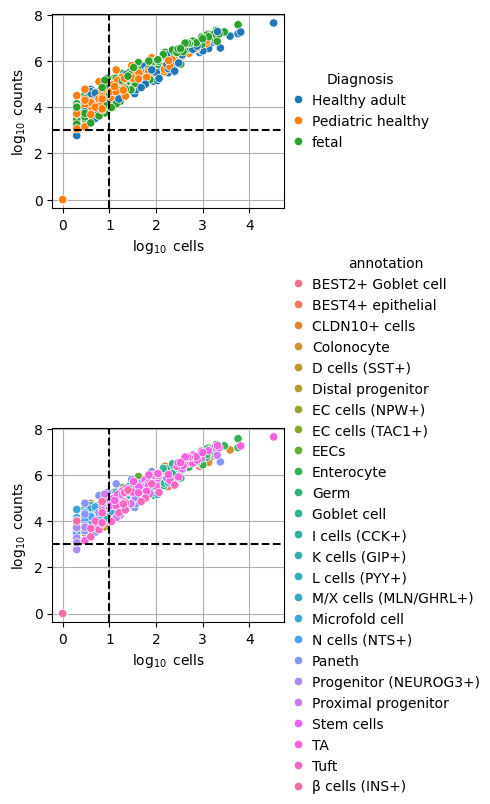

In [ ]:
dc.pl.filter_samples(
    adata=Elm_Gut_pB,
    groupby=["Diagnosis", "annotation"],
    min_cells=10,
    min_counts=1000,
    figsize=(5, 8),
)

In [ ]:
# This is applying the filter in-place..
dc.pp.filter_samples(Elm_Gut_pB, min_cells=10, min_counts=1000)

In [ ]:
Elm_Gut_pB

AnnData object with n_obs × n_vars = 289 × 30263
    obs: 'Sample name', 'annotation', 'Diagnosis', 'Age', 'Gender', '10X', 'predicted_doublets', 'category', 'Age_group', 'psbulk_cells', 'psbulk_counts'
    var: 'gene_ids', 'feature_types'
    layers: 'psbulk_props'

In [ ]:
Elm_Gut_pB.obs.annotation.value_counts()

,count
annotation,
TA,32
Stem cells,30
Goblet cell,29
Enterocyte,29
BEST4+ epithelial,21
Colonocyte,17
Proximal progenitor,15
Paneth,14
Distal progenitor,11


In [ ]:
Elm_Gut_pB.obs.annotation.value_counts().shape

(23,)

In [ ]:
Elm_Gut_pB.obs.Diagnosis.value_counts()

,count
Diagnosis,
fetal,173
Healthy adult,64
Pediatric healthy,52


In [ ]:
Elm_Gut_pB.obs.category.value_counts()

,count
category,
Epithelial,289


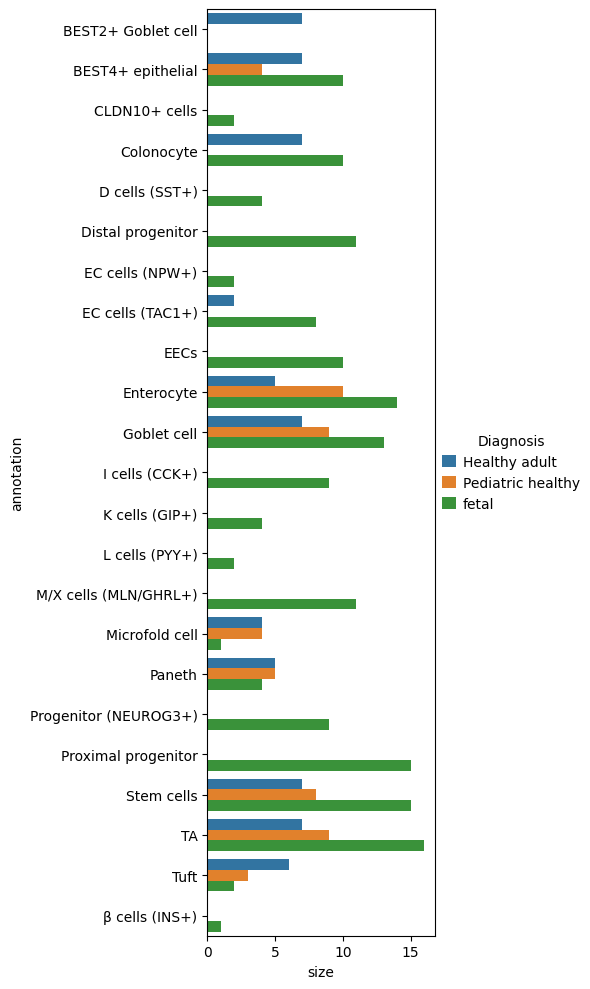

In [ ]:
dc.pl.obsbar(adata=Elm_Gut_pB, y="annotation", hue="Diagnosis", figsize=(6, 10))

# Write out the 'Gut' pB

In [ ]:
# Write out the 'LBowel' pseudobulk data
# 13Apr2026
Elm_Gut_pB.write_h5ad(os.path.join(my_dir,"GutAtlas.dat/Elm_Gut_pB.h5ad"))

# Session hist.

In [ ]:
%watermark -u -n -t -z -m --iversions --jupyter_env

Last updated: Mon, 13 Apr 2026 17:08:42 UTC

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.6.113+
Machine     : x86_64
Processor   : x86_64
CPU cores   : 8
Architecture: 64bit

decoupler : 2.1.6
google    : 3.0.0
matplotlib: 3.10.0
numpy     : 2.0.2
pandas    : 2.3.3
scanpy    : 1.12.1
scipy     : 1.16.3

Jupyter enviroment: Google Colab

